Neuron 0 is peak type 2
Neuron 1 is peak type 1
Neuron 2 is peak type 0
Neuron 3 is peak type 0
Neuron 4 is peak type 2
Neuron 5 is peak type 1
Neuron 6 is peak type 0
Neuron 7 is peak type 2
Neuron 8 is peak type 2
Neuron 9 is peak type 1
Number of possible test points to optimize over:  100
Initial test points:  [[0. 8.]
 [1. 4.]
 [5. 4.]
 [9. 8.]]
[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]
[10, 10]


<Figure size 800x600 with 0 Axes>

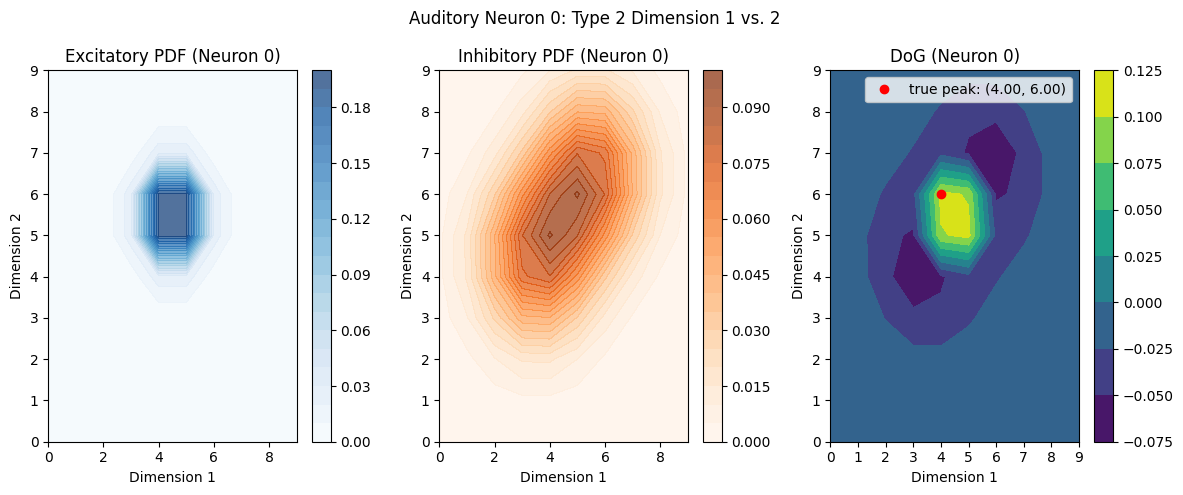

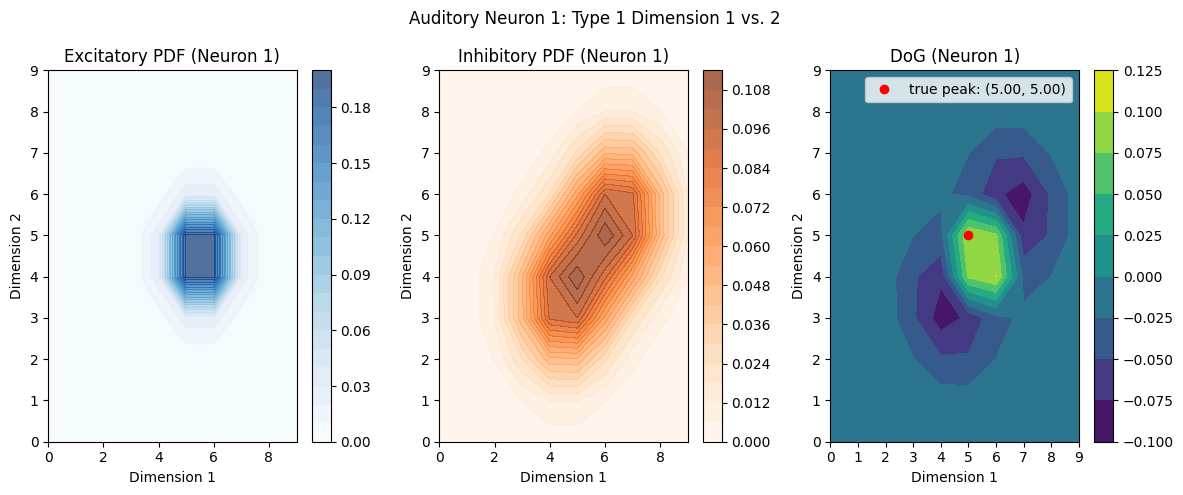

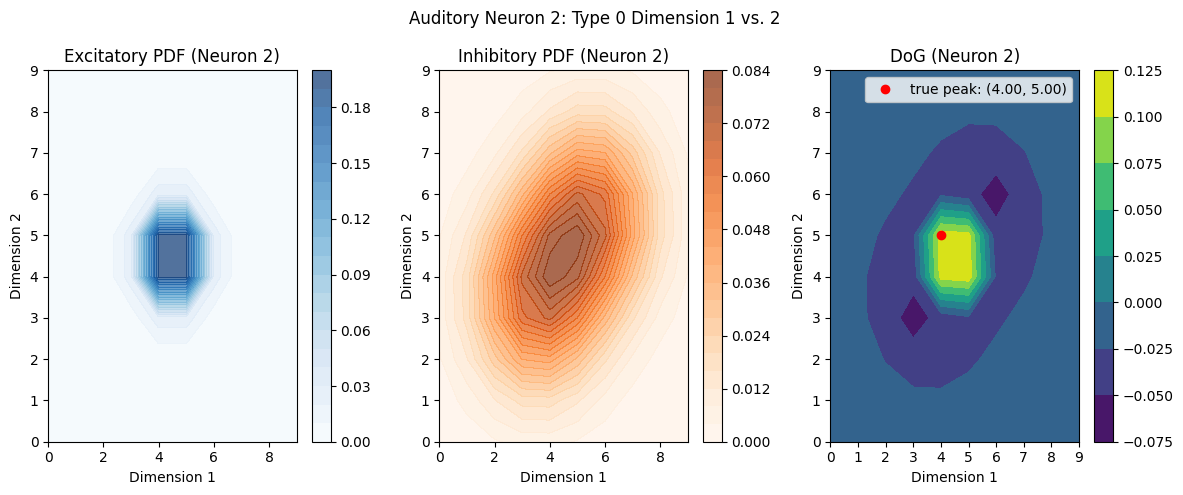

In [ ]:
#Go into the parameters file and set Neurons.SimPop: 'auditory'
#If you would like noise in the tuning curve, set add_noise = True
#set mse_cutoff to desired value
import numpy as np
import os
import yaml

from model.sim_config import Config 
from plot import plot_correct_prediction, plot_tuningcurves, plot_tuningcurves_sampled, plot_stopping_criteria, plot_mse
import matplotlib.pyplot as plt


os.getcwd()
with open("parameters/parameters_indep.yml", "r") as f:
    params = yaml.safe_load(f)
config = Config(file="parameters/parameters_indep.yml")
#results_dict = bayesopt_sampling(config, print_flag=True)
# Stimuli:
#   d: 2
#   x1_range: 9 #5 #1.1 # center frequency
#   x2_range: 10 #1.1 # level (dB)
exs = []
ranges = []
for i in range(1,config.d+1):  # for each dimension
    string = 'x'+str(i)+'_range'
    length = params['Stimuli'][string]
    exs.append(np.arange(length))
    ranges.append(length)
#arrays for d1 and d2
print(exs)
#size of d1 and d2
print(ranges)
N = config.N
SimPop = config.SimPop

#Only need to plot the first three tuning curves! 
plot_tuningcurves(3, SimPop, config) #Ground truth plot for first three neurons since there are three possible tuning curves

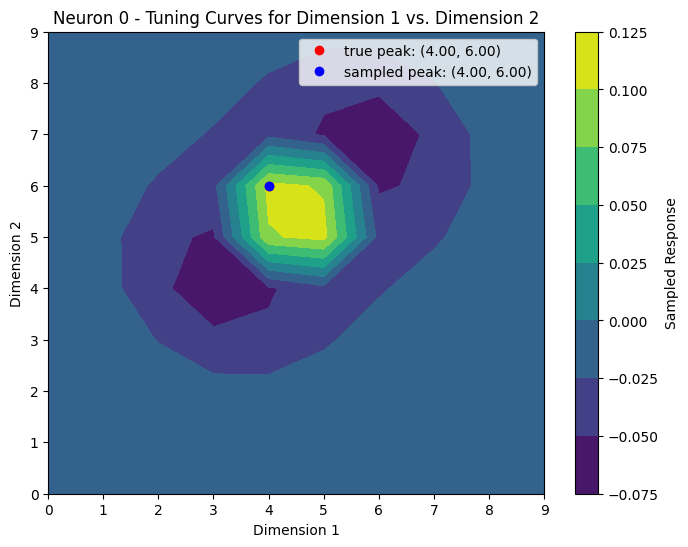

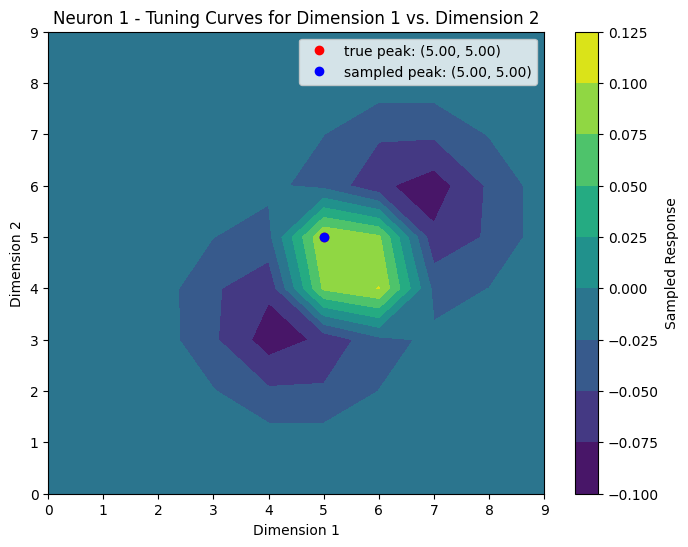

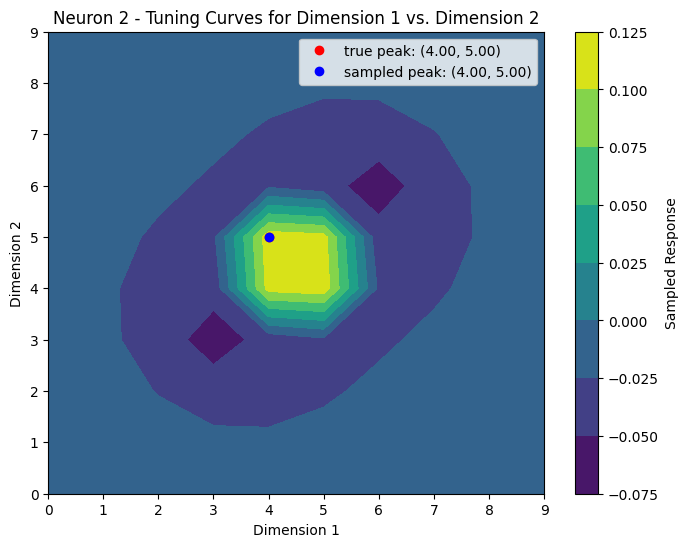

In [5]:
#Sanity check plots: when you sample the stimulus space using sample function, it looks the same as the ground truth plot
for n in range(3): 
    plot_tuningcurves_sampled(n, config, f_peak = None)

Running Bayesian Optimization ...
You're using these kernels: ['rbf', 'rbf'] . The stopping crit is: 0.14
Gamma: [0.55555556 0.55555556]; Nu: 0.1; var: 0.5; eta: 0.01; matern nu (if any) None
Number  0 ; peak of this neuron:  [4. 6.]
Used all  10  tests and did not finish; got close?  [5. 6.]
Number  1 ; peak of this neuron:  [5. 5.]
Used all  10  tests and did not finish; got close?  [0. 1.]
Number  2 ; peak of this neuron:  [4. 5.]
Used all  10  tests and did not finish; got close?  [1. 1.]
Number  3 ; peak of this neuron:  [4. 5.]
Used all  10  tests and did not finish; got close?  [1. 1.]
Number  4 ; peak of this neuron:  [4. 6.]
Used all  10  tests and did not finish; got close?  [0. 1.]
Number  5 ; peak of this neuron:  [5. 5.]
Used all  10  tests and did not finish; got close?  [1. 1.]
Number  6 ; peak of this neuron:  [4. 5.]
Number  7 ; peak of this neuron:  [4. 6.]
Number  8 ; peak of this neuron:  [4. 6.]
Number  9 ; peak of this neuron:  [5. 5.]
Used all  10  tests and did 

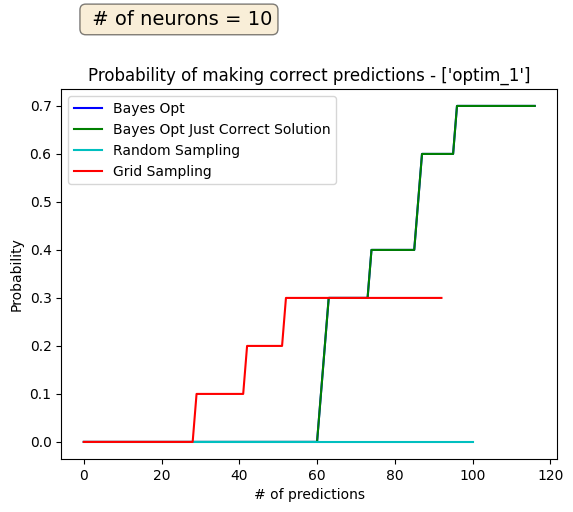

In [6]:
from model.bayesopt_sampling import bayesopt_sampling 
from model.random_sampling import random_sampling
from model.grid_sample import grid_sampling
results_dict = bayesopt_sampling(config, print_flag=True)
Pr_list_all = results_dict['Pr_list'] #
Pr_list_correct_solution_all = results_dict['Pr_list_correct_solution'] 
stopping_allN_all = results_dict['stopping_allN']
rsPr_list = random_sampling(config, print_flag=True)
gsPr_list = grid_sampling(config, print_flag=True)
optimizers = list(config.optimizers.keys())

#   Pr_list_correct_solution: probabilities of correct predictions even if EI is still above stopping criteria (blue line)
# Pr_list: both correct peak AND EI < stopping_crit (green line on plot)
plot_correct_prediction(N=config.N, Pr_list=Pr_list_all, Pr_list_correct_solution = Pr_list_correct_solution_all, rsPr_list=rsPr_list, gsPr_list = gsPr_list, optimizer_name=optimizers)

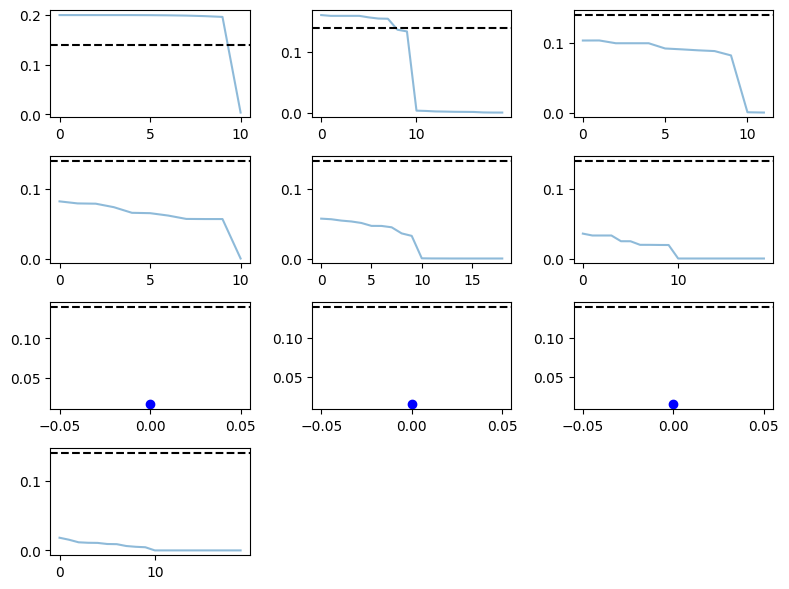

In [7]:
from plot import plot_stopping_criteria, plot_peak_value, plot_run_time, plot_tuningcurves, plot_tuningcurves_eval, plot_tuningcurves_sampled, plot_mse
plot_stopping_criteria(stopping_allN =results_dict['stopping_allN'], stopping_crit = float(config.optimizers['optim_1']['stopping_crit']), EI_or_PI = "EI")

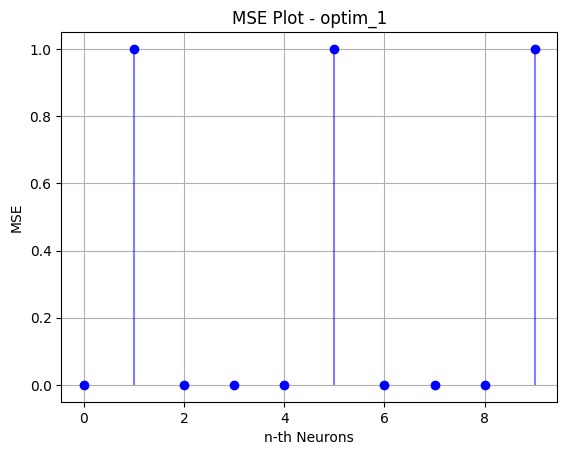

In [8]:
plot_mse(mse_final=results_dict['mse_final'], optimizer_name=optimizers[0])

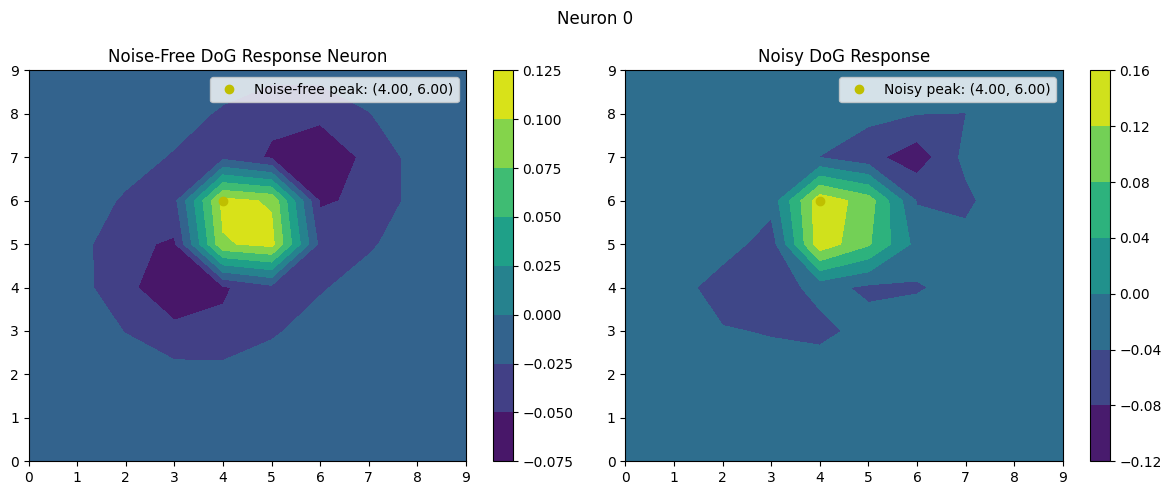

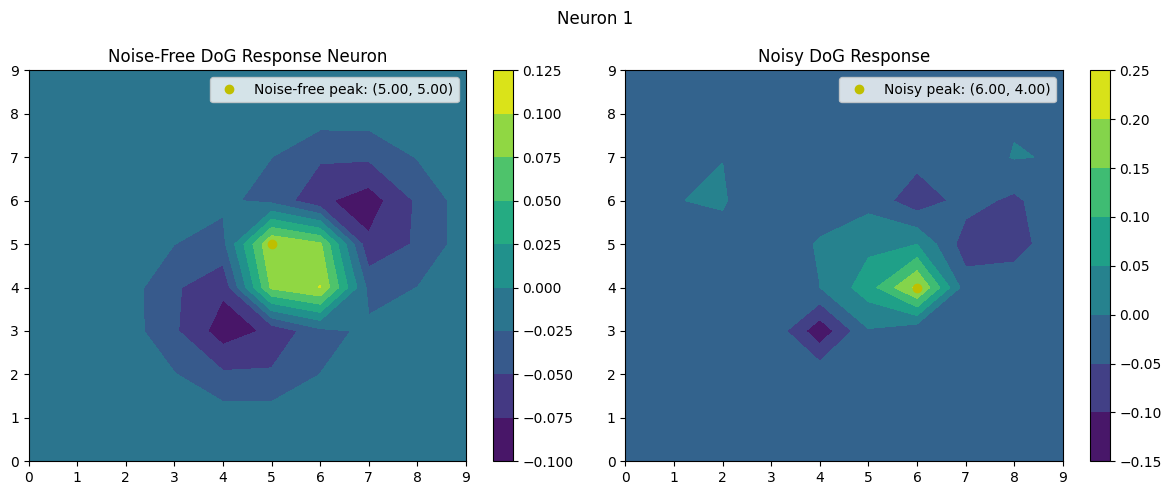

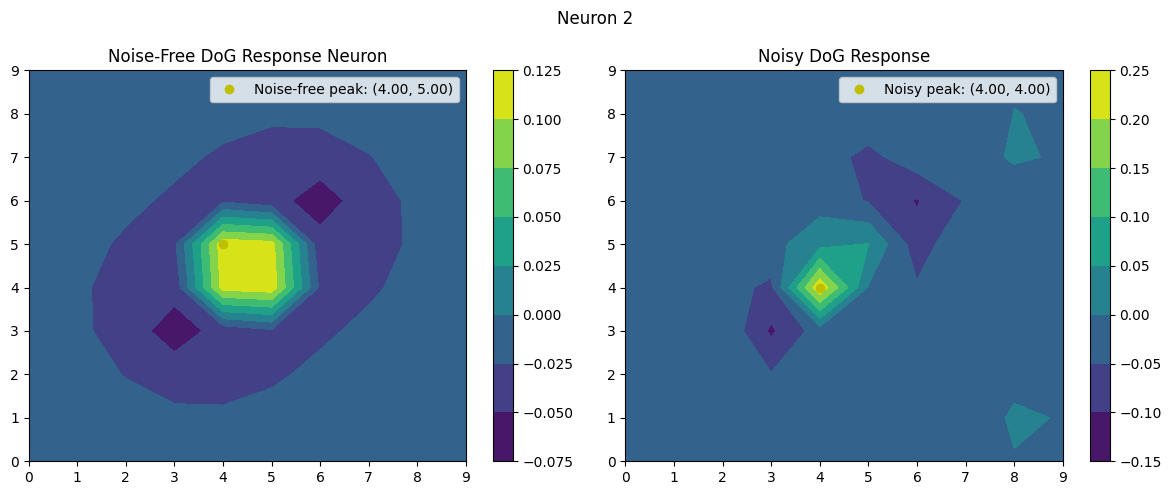

In [12]:
#When you set add_noise in parameters file True:
from utils.plot_noisy_and_clean_tuning import plot_noisy_and_clean_tuning
for n in range(3): 
    plot_noisy_and_clean_tuning(config, n)

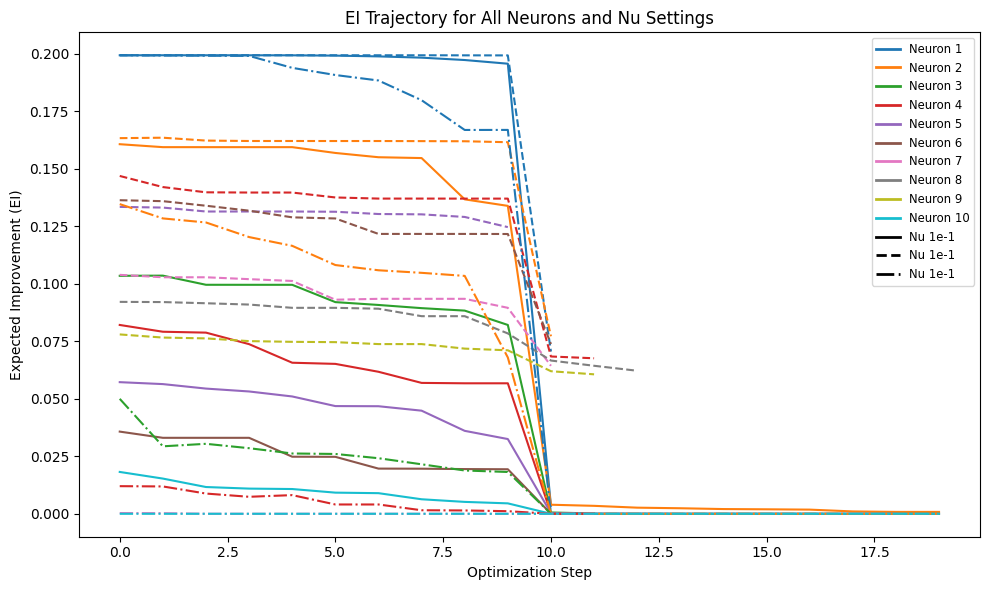

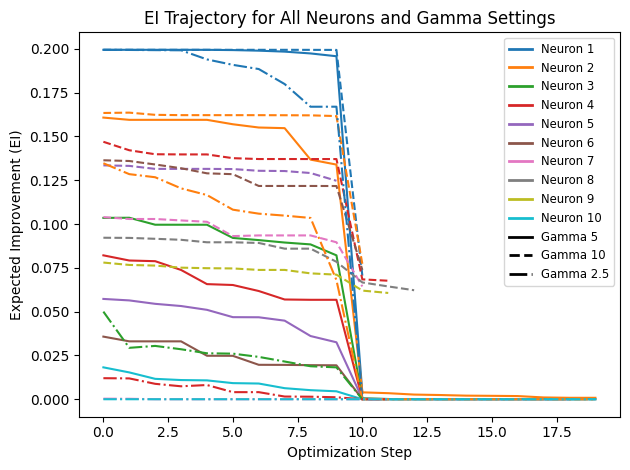

In [14]:
#To try plotting EI trajectory for all neurons as a function of gamma and nu, use this command 
#will pull from all of your runs in the output folder plus the most recent run
from utils.stop_functions_plots import stop_functions_plots
stop_functions_plots(section_key='stopping_allN')

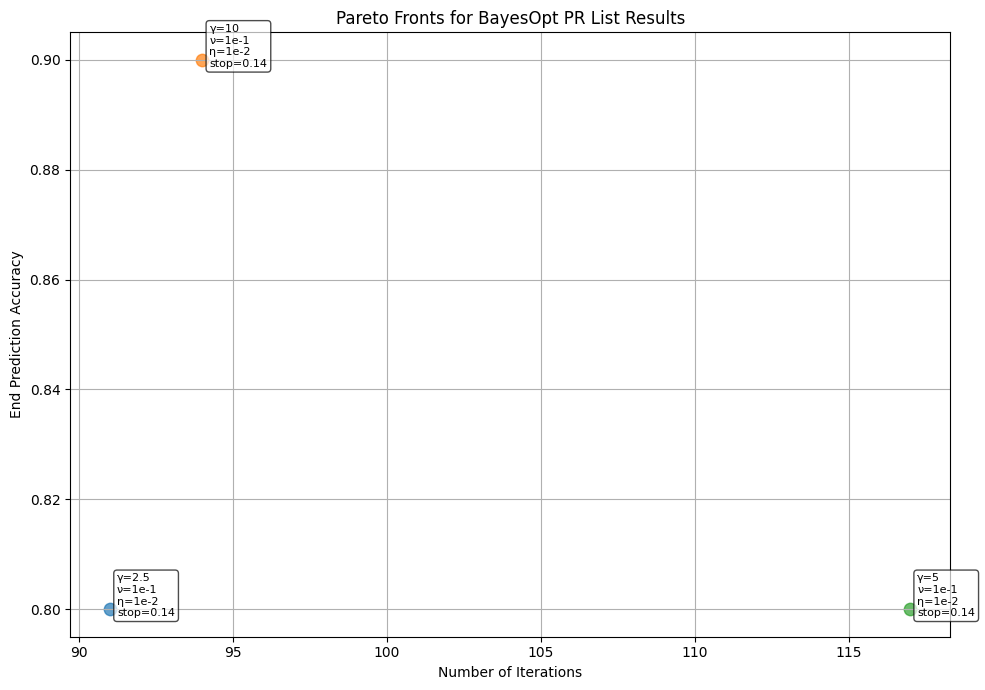

In [17]:
#Once you start saving results to output folder (by running in terminal), try these commands
from model.optimizer import calc_offline_fit 
from utils.plotting_offline_and_online_fits import gathering_data, plotting_offline_and_online_fits
from utils.pareto_plot import gather_hyperparameters, plot_pareto_from_data
# online_grid2, new_xarray, new_yarray = gathering_data(config, results_file, 1) #last argument is the neuron index, here neuron 1
# f, sigma = calc_offline_fit(new_xarray, new_yarray, config, config.kernels)
#plotting_offline_and_online_fits(config, f, online_grid2, 1) #last argument is the neuron index
run_data = gather_hyperparameters(output_dir='output', section_key='Pr_list')
plot_pareto_from_data(run_data)